In [19]:
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import sys

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

In [20]:
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, activation_fun='tanh', bias=True):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size=input_size,
                          hidden_size=hidden_size,
                          num_layers=num_layers,
                          nonlinearity=activation_fun,
                          bias=bias)
        
        # linear layer to map the hidden state to the output
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x, h0=None):
        x, hn = self.rnn(x, h0) # if h0 is None, the RNN will initialize it to zeros
        x = self.linear(x)
        return x, hn

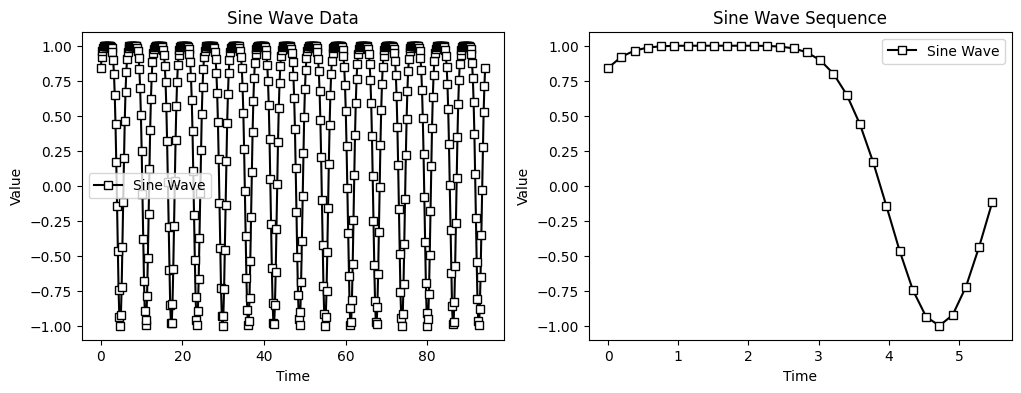

In [21]:
input_size = 1 # number of features in the input
hidden_size = 9 # number of features in the hidden state
num_layers = 1 # number of recurrent layers
sequence_length = 30 # length of the input sequence, this value is obtained playing with the visualization.
batch_size = 1 # number of sequences in a batch

N = 500
t = torch.linspace(0, 30 * np.pi, N) # time vector
sine_data = torch.sin(t + torch.cos(t)) # sine wave with 10 periods over the range of N points

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(t.numpy(), sine_data.numpy(), "ks-", label="Sine Wave", markerfacecolor="w")
ax[0].set_title("Sine Wave Data")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Value")
ax[0].legend()

# plot one sequence of length `sequence_length` from the sine wave
# to check if we have enough sequence length to see the pattern. We can play with values between 20 and 50 to see how it affects the model's ability to learn the pattern.
ax[1].plot(t[:sequence_length].numpy(), sine_data[:sequence_length].numpy(), "ks-", label="Sine Wave", markerfacecolor="w")
ax[1].set_title("Sine Wave Sequence")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Value")
ax[1].legend()
plt.show()

# with N=500 and sequence_length=40, we see that the pattern is visible.

# Let's try to predict the value, not just the sign

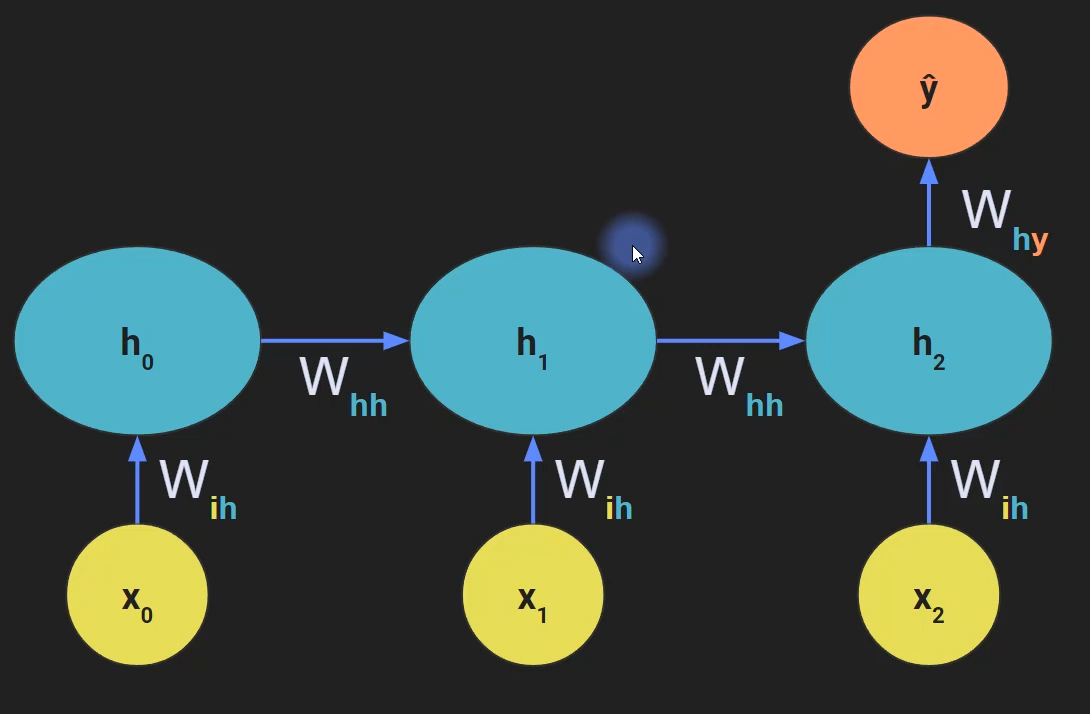

In [1]:
# the output of the hidden layer is called the hidden state (h_t), and it is what is passed from one time step to the next.
# the hidden state is what allows the RNN to have memory and learn patterns over time.

# the weights matrix is the same for all time steps, only update during training and through backpropagation, this means it is updated every epoch, but not at each time step.
# even the weights are shared across all time steps, because the information is passed through the hidden state, these states
# are different at each time step, and the model can learn to use this information to make predictions. 

# X0 represents the first element of the sequence from the sine wave, and h0 is the initial hidden state, which is initialized to zeros by default. 
# [x0, x1, ..., x29] represents 30 time steps.

# The RNN processes the input sequence and updates the hidden state at each time step, allowing it to learn the temporal dependencies in the data.
# h1 = tanh(W_ih * X1 + W_hh * h0 + b) where W_ih is the input-hidden weights, W_hh is the hidden-hidden weights, and b is the bias.

# The hidden state h_t is the model's "memory" — it encodes everything the RNN has seen so far. If you reset it to zero at every window, 
# the model starts blind at the beginning of each window, losing all context from previous data.
# Overlapping windows/sequences is a separate choice — it doesn't affect whether you pass hh or not.

In [ ]:
def train(model, data, loss_fn, optimizer, num_epochs):

    model.train() # set the model to training mode

    losses = np.zeros(num_epochs)
    hh = None # initialize the hidden state to None, the RNN will initialize it to zeros by default

    for epoch in range(num_epochs):
        sequence_losses = []

        for time_i in range(len(data) - sequence_length):
            # prepare the input and target sequences
            input_seq = data[time_i:time_i+sequence_length].view(sequence_length, batch_size, input_size) # contains 30 time steps, each with 1 feature.
            target_seq = data[time_i+sequence_length].view(batch_size, input_size) # target is the next value in the sequence

            # we pass the hidden state from one sequence to the next to allow the model to learn long-term dependencies. 
            # This is important for learning patterns that span across multiple sequences.
            output, hh = model(input_seq, hh) # forward pass
            hh = hh.detach() # detach the hidden state to prevent backpropagating through the entire history
            final_output = output[-1] # take the output of the last time step
            loss = loss_fn(final_output, target_seq) # compute the loss

            optimizer.zero_grad() # clear the gradients
            loss.backward() # backward pass, compute the gradients but once we have passed through all the time steps of the sequence
            optimizer.step() # update the model parameters

            sequence_losses.append(loss.item())

        losses[epoch] = np.mean(sequence_losses) # average loss for the epoch

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {losses[epoch]:.4f}")

    return losses

In [23]:
num_epochs = 30
rnn_net = RNNModel(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers)
optimizer = torch.optim.SGD(rnn_net.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
losses = train(rnn_net, sine_data, loss_fn, optimizer, num_epochs)

Epoch [10/30], Loss: 0.0219
Epoch [20/30], Loss: 0.0060
Epoch [30/30], Loss: 0.0044


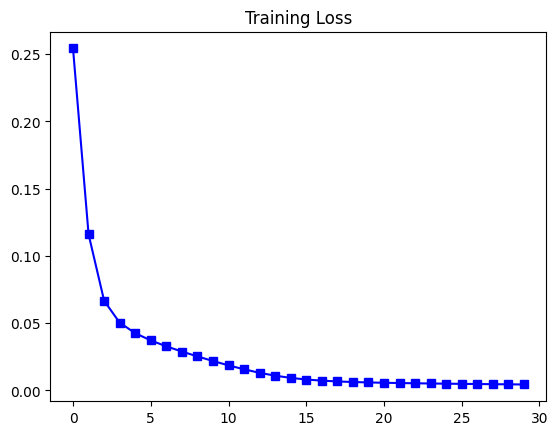

In [24]:
# plot the training loss
plt.plot(losses, "bs-")
plt.title("Training Loss")
plt.show()

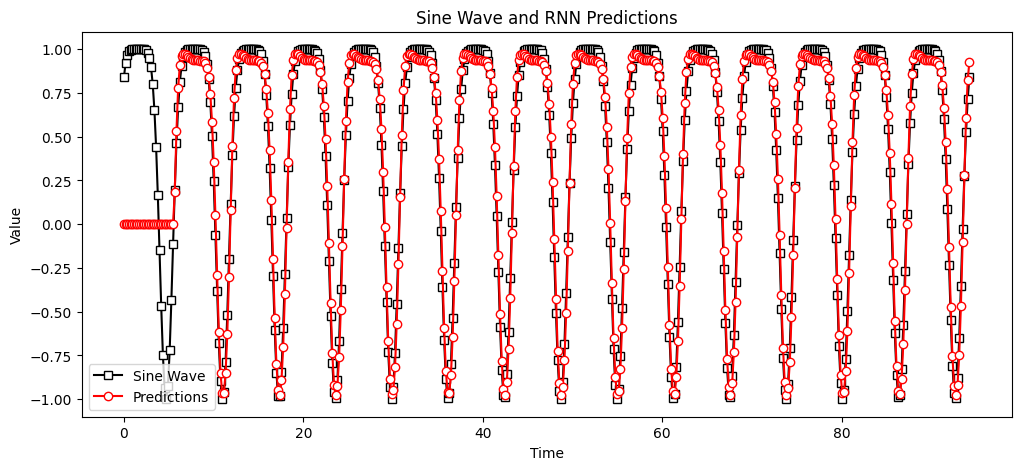

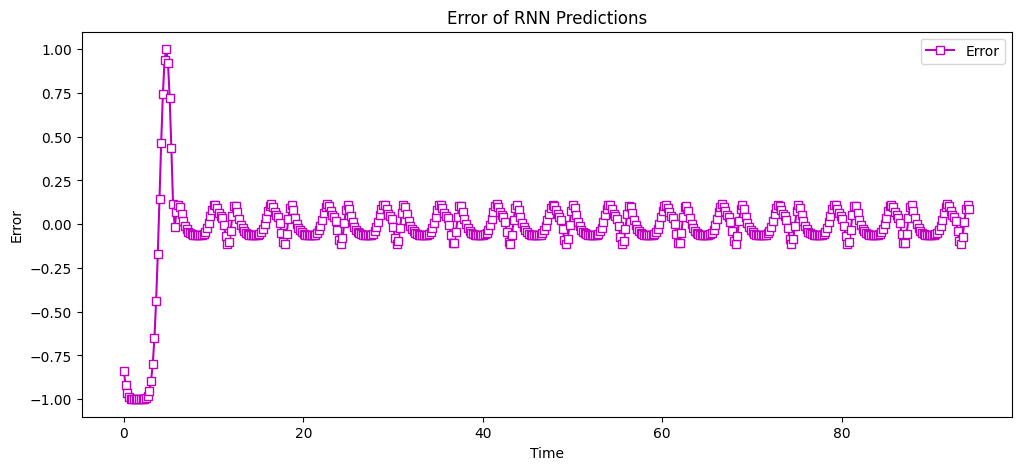

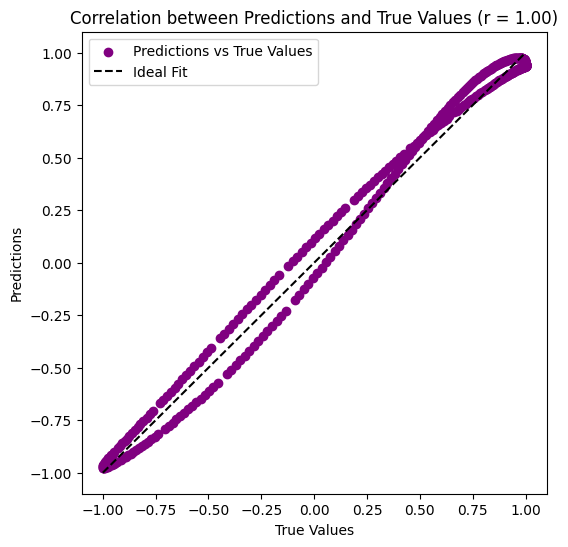

In [25]:
# test the model on training data
h = np.zeros((N, hidden_size)) # initialize hidden state to zeros
predictions = np.zeros((N, 1))
hh = None
for time_i in range(len(sine_data) - sequence_length):
    input_seq = sine_data[time_i:time_i+sequence_length].view(sequence_length, batch_size, input_size)
    output, hh = rnn_net(input_seq, hh) # forward pass
    predictions[time_i + sequence_length] = output[-1].item() # take the output of the last time step
    h[time_i + sequence_length] = hh.detach().numpy().flatten() # store hidden state dynamics

# plot the sine wave and the predictions
plt.figure(figsize=(12, 5))
plt.plot(t.numpy(), sine_data.numpy(), "ks-", label="Sine Wave", markerfacecolor="w")
plt.plot(t.numpy(), predictions, "ro-", label="Predictions", markerfacecolor="w")
plt.title("Sine Wave and RNN Predictions")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

# plt errors
errors = predictions.flatten() - sine_data.numpy()
plt.figure(figsize=(12, 5))
plt.plot(t.numpy(), errors, "ms-", label="Error", markerfacecolor="w")
plt.title("Error of RNN Predictions")
plt.xlabel("Time")
plt.ylabel("Error")
plt.legend()
plt.show()

# plot correlation between predictions and true values
plt.figure(figsize=(6, 6))
plt.scatter(sine_data[sequence_length:], predictions[sequence_length:], color="purple", label="Predictions vs True Values")
plt.plot([-1, 1], [-1, 1], "k--", label="Ideal Fit")
r = np.corrcoef(sine_data[sequence_length:].numpy(), predictions[sequence_length:].flatten())[0, 1]
plt.title(f"Correlation between Predictions and True Values (r = {r:.2f})")
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.legend()
plt.show()

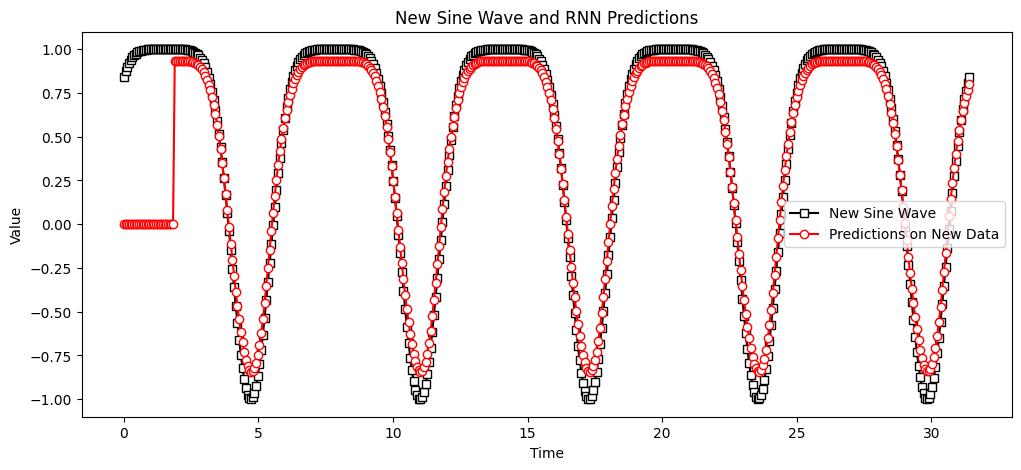

In [26]:
# we dont't know by previous example if the model is learning the pattern or just memorizing the data, so we can test it on a new sine wave with a different phase shift.

# create new data (different frequency)
time = torch.linspace(0, 10 * np.pi, N) # time vector, 10 periods over the range of N points, which changes the frequency of the sine wave
sine_data_new = torch.sin(time + torch.cos(time))

predictions_new = np.zeros((N, 1))
hh = None
for time_i in range(len(sine_data_new) - sequence_length):
    input_seq = sine_data_new[time_i:time_i+sequence_length].view(sequence_length, batch_size, input_size)
    output, hh = rnn_net(input_seq, hh) # forward pass
    predictions_new[time_i + sequence_length] = output[-1].item() # take the output of the last time step

# plot the new sine wave and the predictions
plt.figure(figsize=(12, 5))
plt.plot(time.numpy(), sine_data_new.numpy(), "ks-", label="New Sine Wave", markerfacecolor="w")
plt.plot(time.numpy(), predictions_new, "ro-", label="Predictions on New Data", markerfacecolor="w")
plt.title("New Sine Wave and RNN Predictions")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

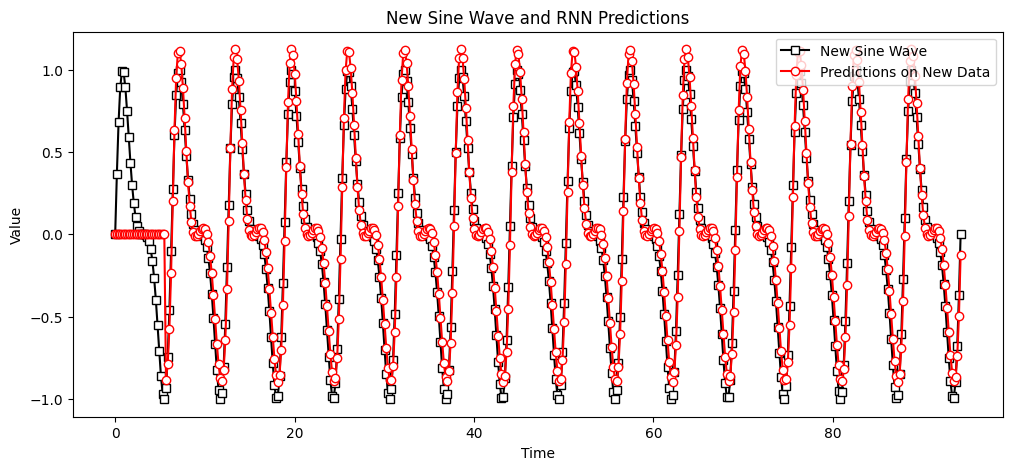

In [27]:
# we dont't know by previous example if the model is learning the pattern or just memorizing the data, so we can test it on a new sine wave with a different phase shift.

# create new data (different function)
time = torch.linspace(0, 30 * np.pi, N)
sine_data_new = torch.sin(time + torch.sin(time)) 

predictions_new = np.zeros((N, 1))
hh = None
for time_i in range(len(sine_data_new) - sequence_length):
    input_seq = sine_data_new[time_i:time_i+sequence_length].view(sequence_length, batch_size, input_size)
    output, hh = rnn_net(input_seq, hh) # forward pass
    predictions_new[time_i + sequence_length] = output[-1].item() # take the output of the last time step


# plot the new sine wave and the predictions
plt.figure(figsize=(12, 5))
plt.plot(time.numpy(), sine_data_new.numpy(), "ks-", label="New Sine Wave", markerfacecolor="w")
plt.plot(time.numpy(), predictions_new, "ro-", label="Predictions on New Data", markerfacecolor="w")
plt.title("New Sine Wave and RNN Predictions")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

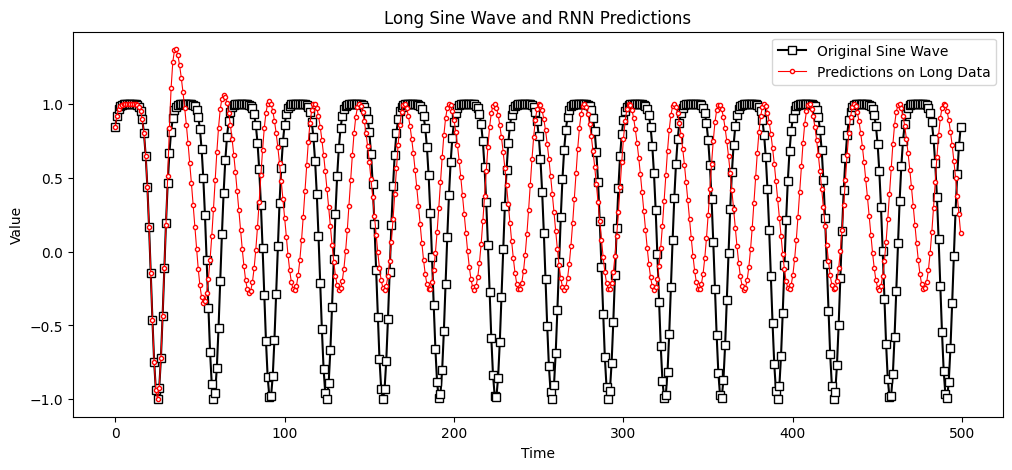

In [ ]:
# test now on extrapolation, instead of using the training data, use next predictions as input to see how the model extrapolates beyond the training data. 
# This is a more challenging test of whether the model has learned the underlying pattern or is just memorizing the data.
extrapolate_data = torch.zeros(N)
extrapolate_data[:N] = sine_data
hh = None

for time_i in range(len(extrapolate_data) - sequence_length):
    input_seq = extrapolate_data[time_i:time_i+sequence_length].view(sequence_length, batch_size, input_size)
    output, hh = rnn_net(input_seq, hh)  # no hidden state carry — matches how the model was trained
    hh = hh.detach()  # detach the hidden state to prevent backpropagating through the entire history
    # update the extrapolate_data with the new prediction to see how the model extrapolates beyond the training data
    extrapolate_data[time_i + sequence_length] = output[-1].item()

# build a time axis that covers the full 2*N points
t_long = torch.linspace(0, 2 * 30 * np.pi, 2 * N)

# plot the long sine wave and the predictions
plt.figure(figsize=(12, 5))
plt.plot(sine_data, "ks-", label="Original Sine Wave", markerfacecolor="w")
plt.plot(extrapolate_data.squeeze().detach(), "ro-", label="Predictions on Long Data", markerfacecolor="w", markersize=3, linewidth=0.8)
plt.title("Long Sine Wave and RNN Predictions")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

# we can see it doesnt get the frequency, the mean and the amplitude
# so there is a big difference between predicting using exact data as input and using the model's own predictions as input, which is a common 
# issue in sequence modeling known as "exposure bias".